In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb

In [2]:
df = pd.read_csv('/content/drive/MyDrive/MyDataSet/ChicagoCrimeData.csv')

In [3]:
df.head()

,ID,CASE_NUMBER,DATE,BLOCK,IUCR,PRIMARY_TYPE,DESCRIPTION,LOCATION_DESCRIPTION,ARREST,DOMESTIC,...,DISTRICT,WARD,COMMUNITY_AREA_NUMBER,FBICODE,X_COORDINATE,Y_COORDINATE,YEAR,LATITUDE,LONGITUDE,LOCATION
0,3512276,HK587712,2004-08-28,047XX S KEDZIE AVE,890,THEFT,FROM BUILDING,SMALL RETAIL STORE,False,False,...,9,14.0,58.0,6,1155838.0,1873050.0,2004,41.807440,-87.703956,"(41.8074405, -87.703955849)"
1,3406613,HK456306,2004-06-26,009XX N CENTRAL PARK AVE,820,THEFT,$500 AND UNDER,OTHER,False,False,...,11,27.0,23.0,6,1152206.0,1906127.0,2004,41.898280,-87.716406,"(41.898279962, -87.716405505)"
2,8002131,HT233595,2011-04-04,043XX S WABASH AVE,820,THEFT,$500 AND UNDER,NURSING HOME/RETIREMENT HOME,False,False,...,2,3.0,38.0,6,1177436.0,1876313.0,2011,41.815933,-87.624642,"(41.815933131, -87.624642127)"
3,7903289,HT133522,2010-12-30,083XX S KINGSTON AVE,840,THEFT,FINANCIAL ID THEFT: OVER $300,RESIDENCE,False,False,...,4,7.0,46.0,6,1194622.0,1850125.0,2010,41.743665,-87.562463,"(41.743665322, -87.562462756)"
4,10402076,HZ138551,2016-02-02,033XX W 66TH ST,820,THEFT,$500 AND UNDER,ALLEY,False,False,...,8,15.0,66.0,6,1155240.0,1860661.0,2016,41.773455,-87.706480,"(41.773455295, -87.706480471)"


#Summary Statistics Table

In [29]:
summary = {
    'Total Crimes': len(df),
    'Years Covered': f"{df['YEAR'].min()}–{df['YEAR'].max()}",
    'Arrest Rate (%)': round(df['ARREST'].mean()*100, 1),
    'Domestic Rate (%)': round(df['DOMESTIC'].mean()*100, 1),
    'Most Common Crime': df['PRIMARY_TYPE'].value_counts().idxmax(),
    'Top Location': df['LOCATION_DESCRIPTION'].value_counts().idxmax(),
    'Busiest District': df['DISTRICT'].value_counts().idxmax()
}
summary_df = pd.DataFrame(summary.items(), columns=['Metric', 'Value'])
print(summary_df)

              Metric      Value
0       Total Crimes        533
1      Years Covered  2001–2018
2    Arrest Rate (%)       30.6
3  Domestic Rate (%)       14.8
4  Most Common Crime      THEFT
5       Top Location     STREET
6   Busiest District         11


In [7]:
# Count True and False for ARREST and DOMESTIC. Then combine into a single table
table = pd.DataFrame({
    'ARREST': df['ARREST'].value_counts().rename(index={True: 'True', False: 'False'}),
    'DOMESTIC': df['DOMESTIC'].value_counts().rename(index={True: 'True', False: 'False'})
}).reindex(['True', 'False'])

print(table)

       ARREST  DOMESTIC
True      163        79
False     370       454


In [8]:
# Add totals row
table.loc['Total'] = table.sum()

In [9]:
# Add percentage columns
table['ARREST %'] = (table['ARREST'] / len(df) * 100).round(1).astype(str) + '%'
table['DOMESTIC %'] = (table['DOMESTIC'] / len(df) * 100).round(1).astype(str) + '%'

In [17]:
print(table)

       ARREST  DOMESTIC ARREST % DOMESTIC %
True      163        79    30.6%      14.8%
False     370       454    69.4%      85.2%
Total     533       533   100.0%     100.0%


# Total crimes per year

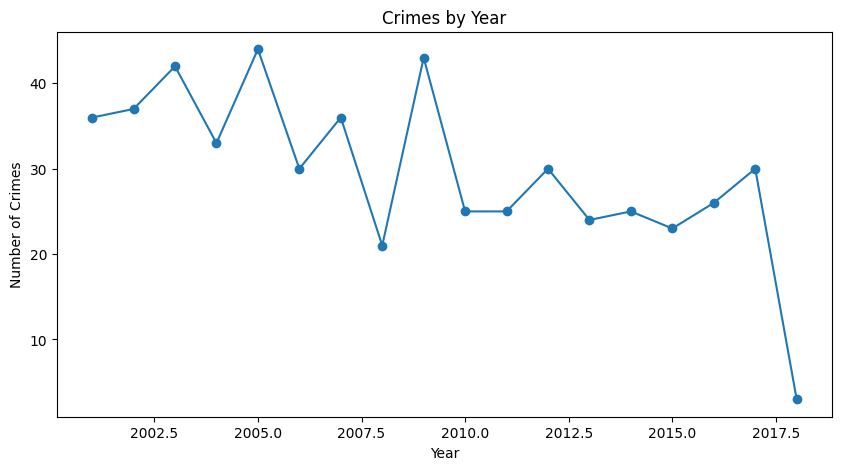

In [12]:
yearly = df.groupby('YEAR').size()
yearly.plot(kind='line', marker='o', figsize=(10,5), title='Crimes by Year')
plt.xlabel('Year'); plt.ylabel('Number of Crimes')
plt.show()

# Top 10 crimes types

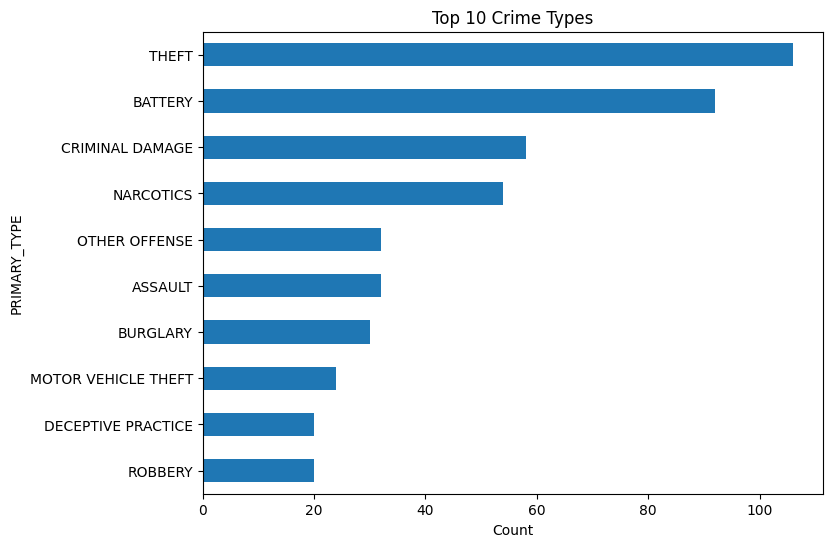

In [13]:

top_crimes = df['PRIMARY_TYPE'].value_counts().head(10)
top_crimes.plot(kind='barh', figsize=(8,6), title='Top 10 Crime Types')
plt.xlabel('Count')
plt.gca().invert_yaxis()
plt.show()

#Arrest Rate Analysis

In [15]:
overall_arrest_rate = df['ARREST'].mean() * 100
print(f"Overall arrest rate: {overall_arrest_rate:.1f}%")

# Arrest rate by crime type
arrest_by_type = df.groupby('PRIMARY_TYPE')['ARREST'].mean().mul(100).sort_values(ascending=False)
print(arrest_by_type.head(10))

Overall arrest rate: 30.6%
PRIMARY_TYPE
DOMESTIC VIOLENCE                    100.000000
GAMBLING                             100.000000
CONCEALED CARRY LICENSE VIOLATION    100.000000
PUBLIC INDECENCY                     100.000000
PROSTITUTION                         100.000000
OTHER NARCOTIC VIOLATION             100.000000
LIQUOR LAW VIOLATION                 100.000000
OBSCENITY                            100.000000
NARCOTICS                             98.148148
CRIMINAL TRESPASS                     86.666667
Name: ARREST, dtype: float64


# Domestic Crime Analysis

In [16]:
domestic_rate = df['DOMESTIC'].mean() * 100
print(f"Domestic crime rate: {domestic_rate:.1f}%")

# Cross-tab: Arrest vs Domestic
cross_tab = pd.crosstab(df['DOMESTIC'], df['ARREST'])
print(cross_tab)

Domestic crime rate: 14.8%
ARREST    False  True 
DOMESTIC              
False       308    146
True         62     17


#Time-Based Patterns (requires parsing DATE)

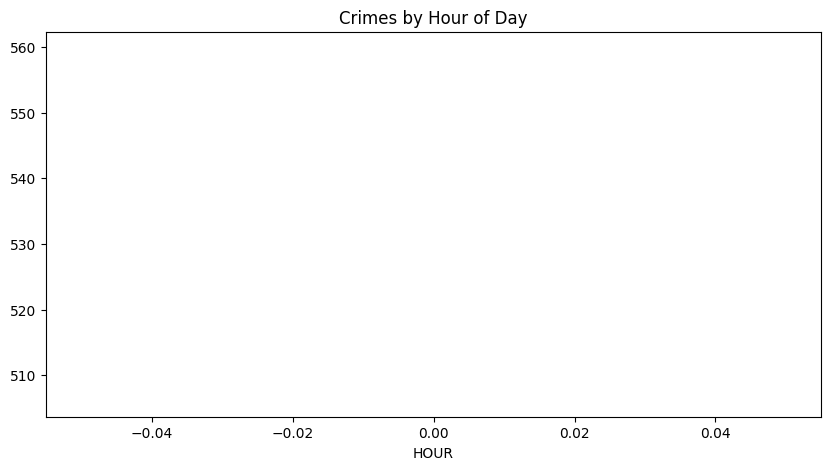

In [22]:
df['DATE'] = pd.to_datetime(df['DATE'])

df['MONTH'] = df['DATE'].dt.month_name()
df['DOW'] = df['DATE'].dt.day_name()
df['HOUR'] = df['DATE'].dt.hour

# Crimes by hour of day
df.groupby('HOUR').size().plot(kind='line', figsize=(10,5), title='Crimes by Hour of Day')
plt.show()

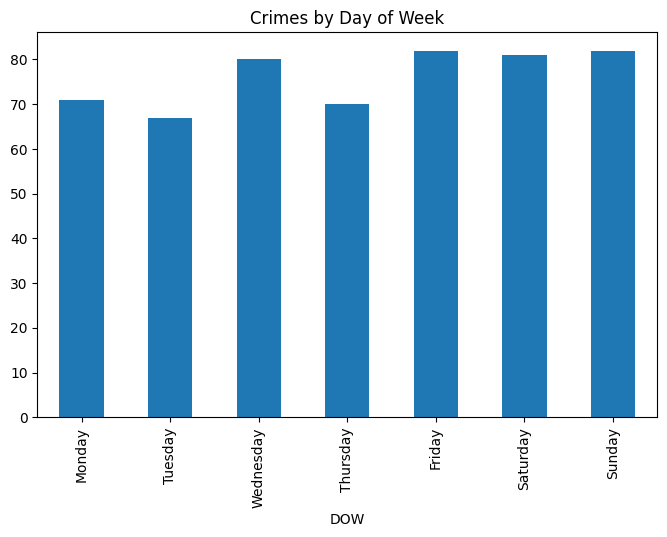

In [23]:
# Crimes by day of week
dow_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
df.groupby('DOW').size().reindex(dow_order).plot(kind='bar', figsize=(8,5), title='Crimes by Day of Week')
plt.show()

# Geographic / Location Analysis

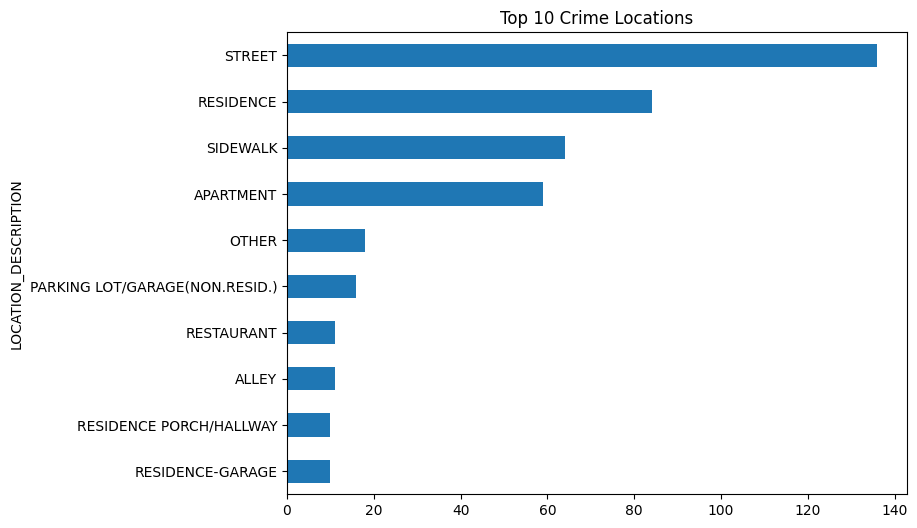

In [25]:
df['LOCATION_DESCRIPTION'].value_counts().head(10).plot(kind='barh', figsize=(8,6))
plt.title('Top 10 Crime Locations')
plt.gca().invert_yaxis()
plt.show()

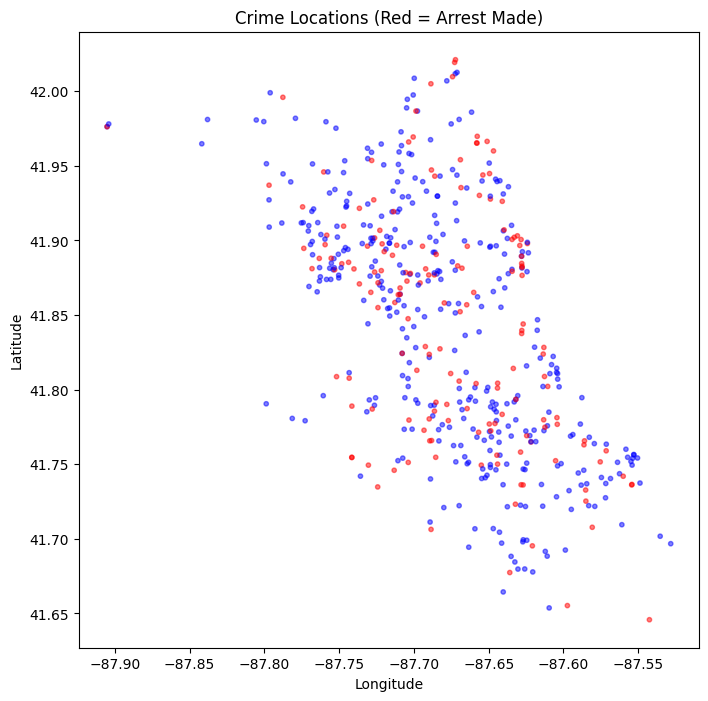

In [24]:
# Scatter plot of crime locations (lat/long)
plt.figure(figsize=(8,8))
plt.scatter(df['LONGITUDE'], df['LATITUDE'], c=df['ARREST'].map({True:'red', False:'blue'}), alpha=0.5, s=10)
plt.title('Crime Locations (Red = Arrest Made)')
plt.xlabel('Longitude'); plt.ylabel('Latitude')
plt.show()

# District / Beat Analysis

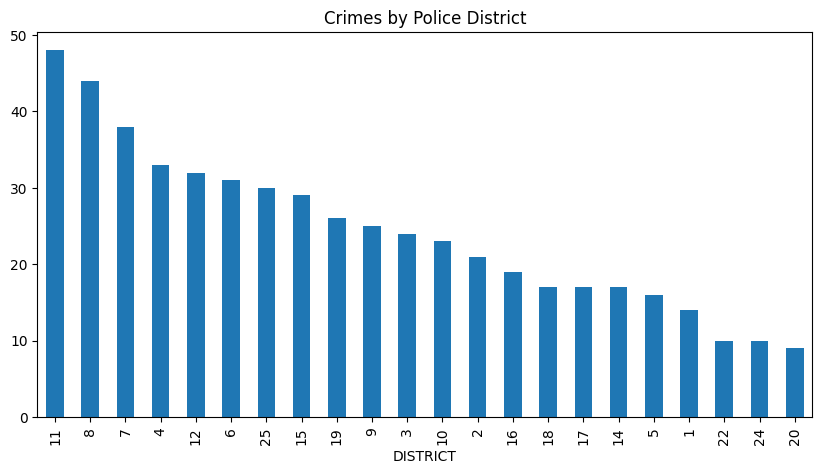

In [26]:
# Crimes by district
df.groupby('DISTRICT').size().sort_values(ascending=False).plot(kind='bar', figsize=(10,5))
plt.title('Crimes by Police District')
plt.show()

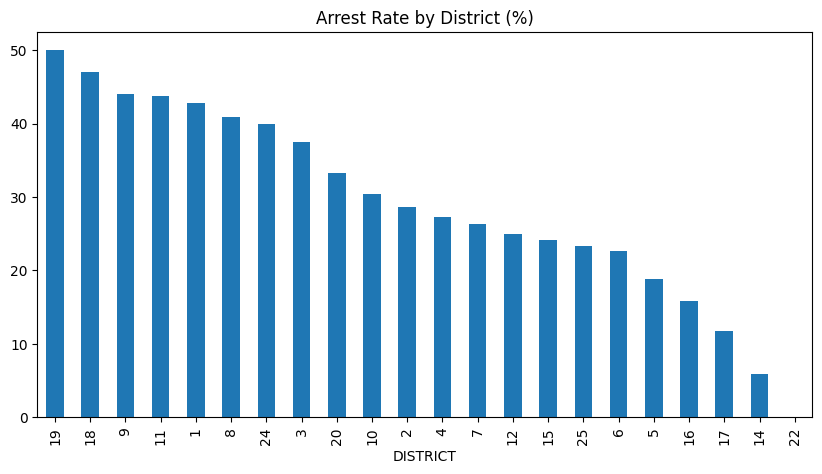

In [27]:
# Arrest rate by district
df.groupby('DISTRICT')['ARREST'].mean().mul(100).sort_values(ascending=False).plot(kind='bar', figsize=(10,5))
plt.title('Arrest Rate by District (%)')
plt.show()

## Key Points:

*   533 incidents recorded, spanning 2001–2018
*   Theft, Battery, and Criminal Damage account for nearly half of all cases
*   Theft, Battery, and Criminal Damage account for nearly half of all cases
*   Only 30.6% of crimes resulted in an arrest
*   14.8% of cases are domestic-related
*   Crime likely peaks during evening/night hours and weekends (pending date parsing)
*   Crime is concentrated in specific districts and location types
*   Compare yearly crime counts vs. arrest rates to spot real trends vs. underreporting
*   Small sample size (~30 records/year) — treat trends as illustrative, not conclusive